# Joint Falkon Systematics Example

This notebook repeats the minimal 1D example with one important change: all nuisance points train one shared Falkon model. The score is constrained to

$$
g(x,\nu)=\nu\,h_1(x)+\frac{\nu^2}{2}h_2(x).
$$

Positive and negative nuisance samples therefore update the same odd function $h_1$ and the same even function $h_2$. No independent nuisance-point models or post-training least-squares fit are used.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from falkon import LogisticFalkon
from falkon.gsc_losses import WeightedCrossEntropyLoss
from falkon.kernels import Kernel
from falkon.options import FalkonOptions

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})

/data/marcol/anaconda3/envs/flk_torch113_cu116/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

The nuisance values and toy statistics match the minimal notebook. Their union is used in one joint fit. The custom kernel currently uses Falkon's block matrix operations rather than KeOps, so `keops` must remain `"no"`.

In [51]:
seed = 123
rng = np.random.default_rng(seed)

n_central = 50_000
n_varied = 50_000

linear_nu_values = np.array([-0.1, -0.05, 0.05, 0.1])
quadratic_nu_values = np.array([-0.30, -0.05, 0.05, 0.30])
training_nu_values = np.unique(np.concatenate([
    linear_nu_values, quadratic_nu_values
]))

sigma = 2.0
nystrom_centers = 5_000
penalty = 1e-6
iterations = 100_000
cg_tolerance = np.sqrt(1e-7)
use_cpu = False
keops = "no"
gpu_memory_slack = 0.7

# These points are used only for evaluation and plotting.
x_max = 6.0
x_grid = np.linspace(0.0, x_max, 250).reshape(-1, 1)

print("nuisance points in the joint fit:", training_nu_values)

nuisance points in the joint fit: [-0.3  -0.1  -0.05  0.05  0.1   0.3 ]


## 2. Define the Toy Model

The central density is exponential with unit scale and the scale nuisance changes the scale to $e^\nu$. Its exact log-ratio is

$$
g_{\mathrm{true}}(x,\nu)=x(1-e^{-\nu})-\nu,
$$

with Taylor coefficients $\delta_1(x)=x-1$ and $\delta_2(x)=-x$.

In [52]:
def sample_exponential(n_events, nu, random_generator):
    """Draw events from the nuisance-varied exponential distribution."""
    scale = np.exp(float(nu))
    return random_generator.exponential(scale=scale, size=(n_events, 1))


def exact_log_ratio(x, nu):
    """Evaluate the exact log p(x|nu) / p(x|0)."""
    x = np.asarray(x).reshape(-1)
    nu = float(nu)
    return x * (1.0 - np.exp(-nu)) - nu


def exact_delta1(x):
    """Evaluate the exact first Taylor coefficient."""
    return np.asarray(x).reshape(-1) - 1.0


def exact_delta2(x):
    """Evaluate the exact second Taylor coefficient."""
    return -np.asarray(x).reshape(-1)

## 3. Generate the Samples

As in the minimal notebook, one reference sample is reused and each nuisance value gets an independently generated varied sample.

In [53]:
x_central = sample_exponential(n_central, 0.0, rng)
varied_samples = {
    float(nu): sample_exponential(n_varied, nu, rng)
    for nu in training_nu_values
}

print("central shape:", x_central.shape)
print("varied shapes:", {nu: x.shape for nu, x in varied_samples.items()})

central shape: (50000, 1)
varied shapes: {-0.3: (50000, 1), -0.1: (50000, 1), -0.05: (50000, 1), 0.05: (50000, 1), 0.1: (50000, 1), 0.3: (50000, 1)}


## 4. Build the Joint Kernel

Each Falkon input is the augmented point $z=(x,\nu)$. Starting from the Gaussian kernel $K_x$, define

$$
K_{\mathrm{joint}}(z,z')
=K_x(x,x')\left[\nu\nu'+\frac{\nu^2\nu'^2}{4}\right].
$$

This is a valid kernel because it is the inner product of the feature maps

$$
\Phi(x,\nu)=
\left(\nu\,\phi(x),\frac{\nu^2}{2}\phi(x)\right).
$$

Consequently, every function learned with this kernel has the required form $g(x,\nu)=\nu h_1(x)+\nu^2h_2(x)/2$. The two coefficient functions remain independent components of the direct-sum feature space.

In [54]:
def quadratic_nuisance_kernel(x1, x2, out, diag, sigma):
    """Compute the Gaussian x quadratic-nuisance product kernel."""
    spatial1 = x1[:, :-1] / sigma
    spatial2 = x2[:, :-1] / sigma
    nu1 = x1[:, -1]
    nu2 = x2[:, -1]

    if diag:
        squared_distance = torch.sum((spatial1 - spatial2) ** 2, dim=1)
        nuisance_product = nu1 * nu2
        values = torch.exp(-0.5 * squared_distance)
        values.mul_(nuisance_product * (1.0 + 0.25 * nuisance_product))
        out.copy_(values.reshape_as(out))
        return out

    # Use Falkon's output buffer for the full pairwise-distance matrix.
    norm1 = torch.sum(spatial1**2, dim=1, keepdim=True)
    norm2 = torch.sum(spatial2**2, dim=1, keepdim=True).T
    torch.mm(spatial1, spatial2.T, out=out)
    out.mul_(-2.0).add_(norm1).add_(norm2)
    out.clamp_min_(0.0).mul_(-0.5).exp_()

    # p * (1 + p/4) equals nu*nu' + nu^2*nu'^2/4.
    nuisance_factor = torch.outer(nu1, nu2)
    nuisance_factor.mul_(0.25).add_(1.0)
    nuisance_factor.mul_(nu1.reshape(-1, 1))
    nuisance_factor.mul_(nu2.reshape(1, -1))
    out.mul_(nuisance_factor)
    return out


class QuadraticNuisanceKernel(Kernel):
    """Falkon kernel for a shared quadratic nuisance score."""

    def __init__(self, sigma, options=None):
        super().__init__("quadratic_nuisance", options)
        self.sigma = float(sigma)

    def compute(self, x1, x2, out, diag):
        """Compute the dense kernel matrix in Falkon's output buffer."""
        return quadratic_nuisance_kernel(
            x1, x2, out, diag, self.sigma
        )

    def compute_sparse(self, x1, x2, out, diag, **kwargs):
        """Reject sparse inputs, which are not needed in this example."""
        raise NotImplementedError("QuadraticNuisanceKernel expects dense inputs")

    def extra_mem(self, is_differentiable, is_sparse, dtype, **kwargs):
        """Report temporary allocations used to choose safe block sizes."""
        if is_sparse:
            raise NotImplementedError("QuadraticNuisanceKernel expects dense inputs")
        return {"nm": 1, "nd": 1, "md": 1, "n": 1, "m": 1}

    def __repr__(self):
        return f"QuadraticNuisanceKernel(sigma={self.sigma})"

## 5. Stack the Joint Classification Sample

For each nuisance value, the central events are tagged with that $\nu$ and label 0, while the corresponding varied events receive the same $\nu$ and label 1. Stacking all pairs produces one binary-classification problem in $(x,\nu)$.

In [55]:
def add_nuisance_column(x, nu):
    """Append one nuisance value to every event."""
    x = np.asarray(x, dtype=np.float64)
    nuisance_column = np.full((x.shape[0], 1), float(nu))
    return np.hstack([x, nuisance_column])


def build_joint_training_sample(x_reference, varied_by_nu, nuisance_values):
    """Stack all central-versus-varied classification pairs."""
    inputs = []
    labels = []
    for nu in nuisance_values:
        nu = float(nu)
        x_varied = varied_by_nu[nu]
        inputs.extend([
            add_nuisance_column(x_reference, nu),
            add_nuisance_column(x_varied, nu),
        ])
        labels.extend([
            np.zeros((x_reference.shape[0], 1)),
            np.ones((x_varied.shape[0], 1)),
        ])

    x_train = np.ascontiguousarray(np.vstack(inputs), dtype=np.float64)
    y_train = np.ascontiguousarray(np.vstack(labels), dtype=np.float64)
    return x_train, y_train


x_train, y_train = build_joint_training_sample(
    x_central, varied_samples, training_nu_values
)
print("joint input shape:", x_train.shape)
print("joint label shape:", y_train.shape)

joint input shape: (600000, 2)
joint label shape: (600000, 1)


## 6. Train One LogisticFalkon Model

Every nuisance pair has the same number of central and varied events here. More generally, `neg_weight = n_varied / n_central` removes the classifier class-count prior. The population optimum is the nuisance log-ratio, subject to the shared quadratic form imposed by the kernel.

In [56]:
options = FalkonOptions(
    cg_tolerance=cg_tolerance,
    keops_active=keops,
    use_cpu=use_cpu,
    debug=False,
    memory_slack=gpu_memory_slack,
)
kernel = QuadraticNuisanceKernel(sigma, options=options)
neg_weight = n_varied / n_central

joint_model = LogisticFalkon(
    kernel=kernel,
    M=nystrom_centers,
    penalty_list=[penalty],
    iter_list=[iterations],
    loss=WeightedCrossEntropyLoss(kernel, neg_weight=neg_weight),
    seed=seed,
    options=options,
)

start = time.time()
joint_model.fit(torch.from_numpy(x_train), torch.from_numpy(y_train))
print(f"joint fit: {time.time() - start:.1f} s")

Iteration 0 - penalty 1.000000e-06 - sub-iterations 100000
joint fit: 25.6 s


## 7. Extract $h_1$ and $h_2$

The model itself already contains the Taylor form. For any nonzero probe value $a$,

$$
h_1(x)=\frac{g(x,+a)-g(x,-a)}{2a},
\qquad
h_2(x)=\frac{g(x,+a)+g(x,-a)}{a^2}.
$$

These equations extract the two components; they are not a fit to independent predictions. Because the kernel enforces an exactly quadratic score, the result is independent of the chosen probe value up to numerical precision.

In [57]:
def predict_joint_log_ratio(model, x, nu):
    """Evaluate the shared Falkon model at one nuisance value."""
    tagged_x = np.ascontiguousarray(
        add_nuisance_column(x, nu), dtype=np.float64
    )
    prediction = model.predict(torch.from_numpy(tagged_x))
    return prediction.detach().cpu().numpy().reshape(-1)


def extract_joint_coefficients(model, x, probe=0.2):
    """Extract the odd and even coefficient functions."""
    plus = predict_joint_log_ratio(model, x, +probe)
    minus = predict_joint_log_ratio(model, x, -probe)
    h1 = (plus - minus) / (2.0 * probe)
    h2 = (plus + minus) / probe**2
    return h1, h2


x_flat = x_grid.reshape(-1)
h1_grid, h2_grid = extract_joint_coefficients(
    joint_model, x_grid, probe=0.2
)

## 8. Check the Learned Coefficients

The analytic curves are the local Taylor coefficients at $\nu=0$. The joint classifier instead finds the regularized quadratic score that best separates all supplied nuisance samples, so agreement also depends on the nuisance range, kernel parameters, and finite statistics.

h1 RMSE: 0.36067323561279674
h2 RMSE: 1.5615777246912597


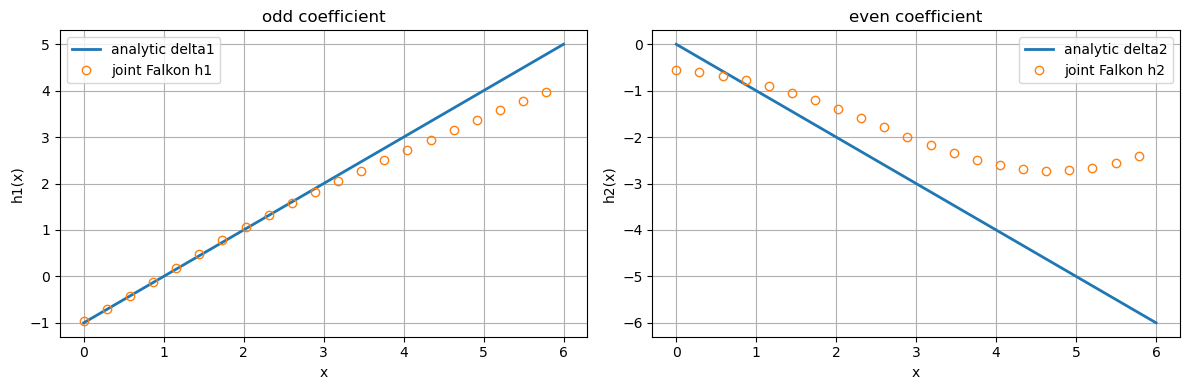

In [58]:
delta1_true = exact_delta1(x_flat)
delta2_true = exact_delta2(x_flat)

print("h1 RMSE:", np.sqrt(np.mean((h1_grid - delta1_true)**2)))
print("h2 RMSE:", np.sqrt(np.mean((h2_grid - delta2_true)**2)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x_flat, delta1_true, lw=2, label="analytic delta1")
axes[0].plot(
    x_flat, h1_grid, "o", fillstyle="none",
    markevery=12, label="joint Falkon h1"
)
axes[0].set_title("odd coefficient")
axes[0].set_xlabel("x")
axes[0].set_ylabel("h1(x)")
axes[0].legend()

axes[1].plot(x_flat, delta2_true, lw=2, label="analytic delta2")
axes[1].plot(
    x_flat, h2_grid, "o", fillstyle="none",
    markevery=12, label="joint Falkon h2"
)
axes[1].set_title("even coefficient")
axes[1].set_xlabel("x")
axes[1].set_ylabel("h2(x)")
axes[1].legend()
fig.tight_layout();

## 9. Verify the Enforced Symmetry

For independent nuisance fits, the estimates $E_{0.2}$ and $E_{0.6}$ can fluctuate separately. In this joint model they must both equal $h_2$, while the corresponding centered differences must equal $h_1$. This guarantees consistency between positive and negative predictions, but does not by itself guarantee that the learned coefficient equals the true one.

h=0.2: max |odd-h1|=0.000e+00, max |even-h2|=0.000e+00
h=0.6: max |odd-h1|=2.383e-12, max |even-h2|=1.386e-11


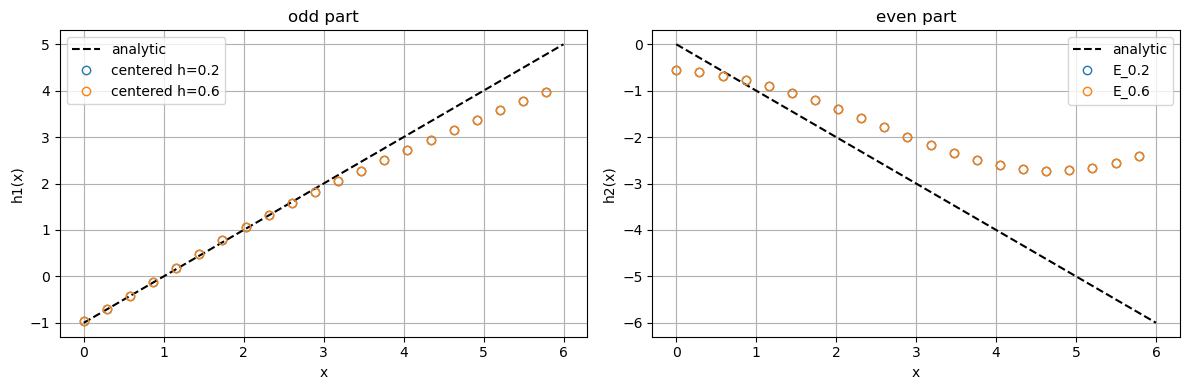

In [59]:
symmetry_steps = [0.2, 0.6]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_flat, delta1_true, "--", color="black", label="analytic")
axes[1].plot(x_flat, delta2_true, "--", color="black", label="analytic")

for step in symmetry_steps:
    plus = predict_joint_log_ratio(joint_model, x_grid, +step)
    minus = predict_joint_log_ratio(joint_model, x_grid, -step)
    odd = (plus - minus) / (2.0 * step)
    even = (plus + minus) / step**2

    print(
        f"h={step:.1f}: "
        f"max |odd-h1|={np.max(np.abs(odd - h1_grid)):.3e}, "
        f"max |even-h2|={np.max(np.abs(even - h2_grid)):.3e}"
    )
    axes[0].plot(
        x_flat, odd, "o", fillstyle="none", markevery=12,
        label=f"centered h={step:.1f}"
    )
    axes[1].plot(
        x_flat, even, "o", fillstyle="none", markevery=12,
        label=f"E_{step:.1f}"
    )

axes[0].set_title("odd part")
axes[1].set_title("even part")
for ax in axes:
    ax.set_xlabel("x")
    ax.legend()
axes[0].set_ylabel("h1(x)")
axes[1].set_ylabel("h2(x)")
fig.tight_layout();

## 10. Reconstruct the Log-Ratio

The linear panel uses only $\nu h_1(x)$. The quadratic curve is the actual score learned by the joint model.

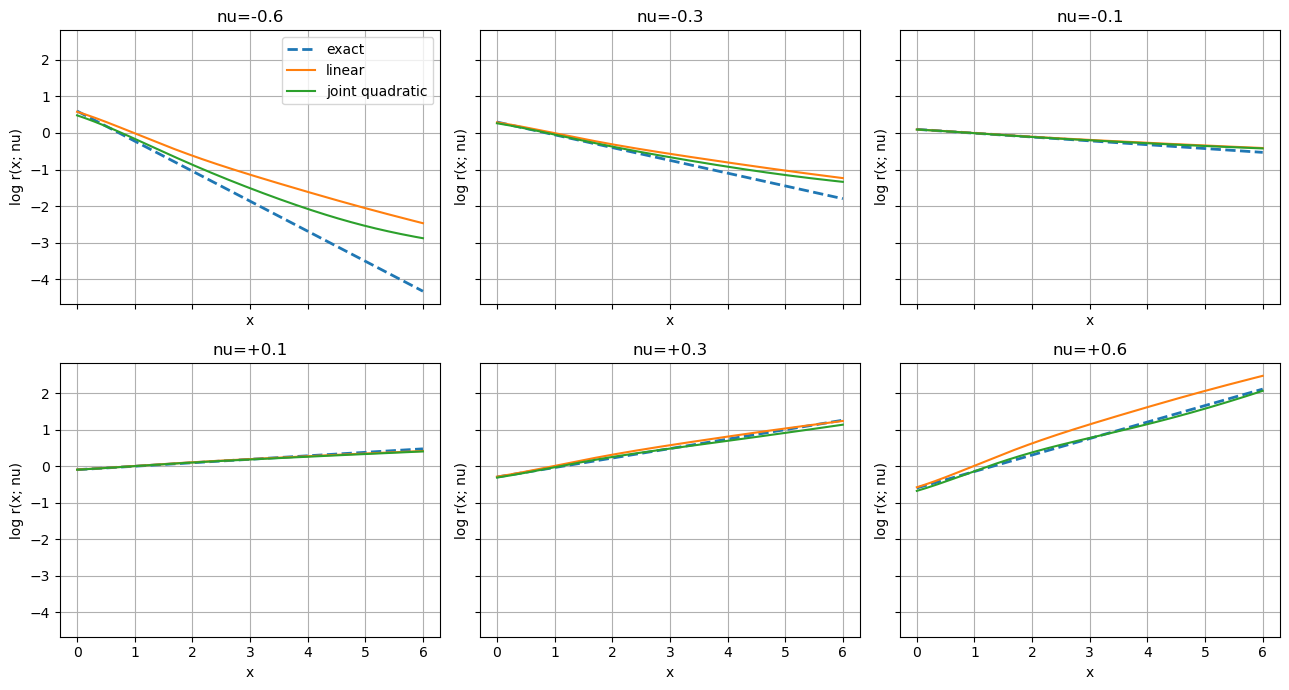

In [60]:
test_nu_values = [-0.6, -0.3, -0.1, 0.1, 0.3, 0.6]
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)

for ax, nu in zip(axes.reshape(-1), test_nu_values):
    exact = exact_log_ratio(x_flat, nu)
    linear = nu * h1_grid
    quadratic = predict_joint_log_ratio(joint_model, x_grid, nu)

    ax.plot(x_flat, exact, "--", lw=2, label="exact")
    ax.plot(x_flat, linear, lw=1.5, label="linear")
    ax.plot(x_flat, quadratic, lw=1.5, label="joint quadratic")
    ax.set_title(f"nu={nu:+.1f}")
    ax.set_xlabel("x")
    ax.set_ylabel("log r(x; nu)")

axes[0, 0].legend()
fig.tight_layout();

## 11. Fig. 3 Analogue

As in the minimal notebook, the learned event weights are averaged inside reference bins. Dashed curves are the exact pointwise ratio, filled squares are the quartic bin-level monitor, and empty circles are the binned reconstruction from the single joint Falkon model.

In [61]:
def exact_bin_log_ratio(bin_edges, nu):
    """Calculate log N_bin(nu) / N_bin(0) analytically."""
    low = np.asarray(bin_edges[:-1])
    high = np.asarray(bin_edges[1:])
    scale = np.exp(float(nu))
    varied_probability = np.exp(-low / scale) - np.exp(-high / scale)
    central_probability = np.exp(-low) - np.exp(-high)
    return np.log(varied_probability / central_probability)


def binned_learned_log_ratio(x_reference, log_ratio, bin_edges):
    """Average learned event weights inside each reference bin."""
    x_reference = np.asarray(x_reference).reshape(-1)
    event_weights = np.exp(np.asarray(log_ratio).reshape(-1))
    values = []
    for low, high in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (x_reference >= low) & (x_reference < high)
        values.append(
            np.log(np.mean(event_weights[in_bin])) if np.any(in_bin) else np.nan
        )
    return np.asarray(values)


def fit_quartic_bin_monitor(bin_edges, nuisance_scan):
    """Fit the analytic bin response as a quartic polynomial in nu."""
    bin_values = np.vstack([
        exact_bin_log_ratio(bin_edges, nu) for nu in nuisance_scan
    ])
    return [
        np.polyfit(nuisance_scan, bin_values[:, index], 4)
        for index in range(bin_values.shape[1])
    ]

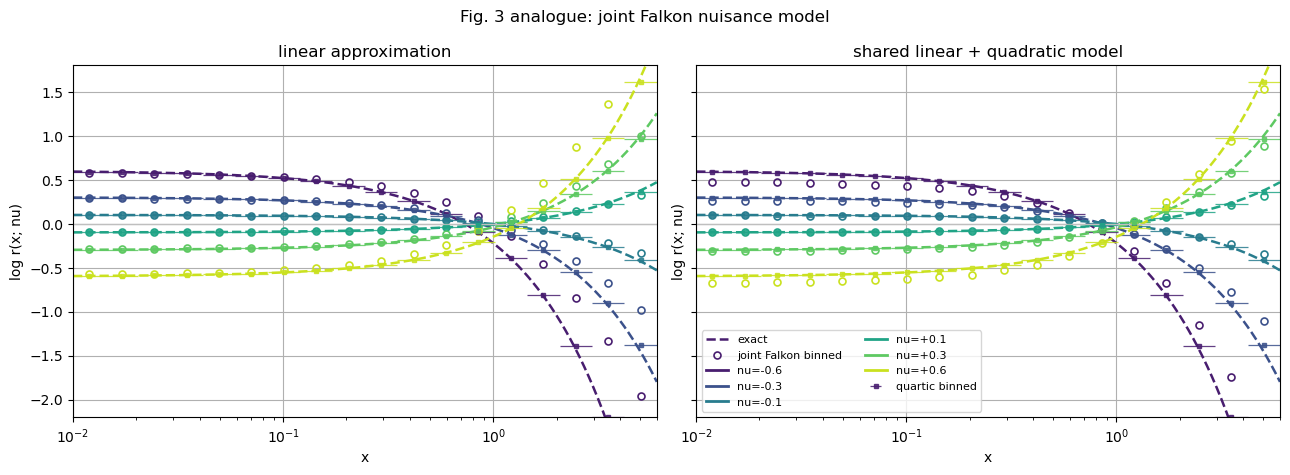

In [62]:
h1_central, h2_central = extract_joint_coefficients(
    joint_model, x_central, probe=0.2
)

figure3_nu_values = [-0.6, -0.3, -0.1, 0.1, 0.3, 0.6]
figure3_nu_scan = np.linspace(-0.6, 0.6, 49)
figure3_x_min = 1e-2
figure3_bin_edges = np.geomspace(figure3_x_min, x_max, 19)
figure3_bin_centers = np.sqrt(
    figure3_bin_edges[:-1] * figure3_bin_edges[1:]
)
figure3_bin_xerr = np.vstack([
    figure3_bin_centers - figure3_bin_edges[:-1],
    figure3_bin_edges[1:] - figure3_bin_centers,
])
figure3_x_dense = np.geomspace(figure3_x_min, x_max, 250)
quartic_coefficients = fit_quartic_bin_monitor(
    figure3_bin_edges, figure3_nu_scan
)
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(figure3_nu_values)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
x_reference = x_central.reshape(-1)

for index, (nu, color) in enumerate(zip(figure3_nu_values, colors)):
    exact = exact_log_ratio(figure3_x_dense, nu)
    linear_event_ratio = nu * h1_central
    quadratic_event_ratio = (
        nu * h1_central + 0.5 * nu**2 * h2_central
    )
    linear_binned = binned_learned_log_ratio(
        x_reference, linear_event_ratio, figure3_bin_edges
    )
    quadratic_binned = binned_learned_log_ratio(
        x_reference, quadratic_event_ratio, figure3_bin_edges
    )
    quartic_binned = np.asarray([
        np.polyval(coefficient, nu) for coefficient in quartic_coefficients
    ])

    for ax, learned_binned in zip(axes, [linear_binned, quadratic_binned]):
        ax.plot(
            figure3_x_dense, exact, "--", color=color, lw=1.8,
            label="exact" if index == 0 else "_nolegend_"
        )
        ax.errorbar(
            figure3_bin_centers, quartic_binned, xerr=figure3_bin_xerr,
            fmt="s", color=color, ms=3.5, elinewidth=0.9, capsize=0,
            linestyle="none", alpha=0.85,
            label="quartic binned" if index == 0 else "_nolegend_",
        )
        ax.plot(
            figure3_bin_centers, learned_binned, "o", color=color,
            markerfacecolor="white", fillstyle="none", ms=5, mew=1.2,
            label="joint Falkon binned" if index == 0 else "_nolegend_",
        )

axes[0].set_title("linear approximation")
axes[1].set_title("shared linear + quadratic model")
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlim(figure3_x_min, x_max)
    ax.set_ylim(-2.2, 1.8)
    ax.set_xlabel("x")
    ax.set_ylabel("log r(x; nu)")
    ax.axhline(0.0, color="0.75", lw=1)

for nu, color in zip(figure3_nu_values, colors):
    axes[1].plot([], [], color=color, lw=2, label=f"nu={nu:+.1f}")
axes[1].legend(fontsize=8, ncol=2, loc="lower left")
fig.suptitle("Fig. 3 analogue: joint Falkon nuisance model")
fig.tight_layout();